# **NLP Fake News Classifier Model Development Notebook**

This notebook will serve as an environment to develop the fake news classifier for our web application. For future development phases, I hope this notebook will serve you well in terms of how the model is made, and its overall documentation in your development.

In this notebook, we aim to achieve the following:

- Load the dataset and prepare the Tagalog Fake News [dataset](https://huggingface.co/datasets/jcblaise/fake_news_filipino) for preprocessing
- Preprocess the dataset for training.
  - Use the following tools at your disposal, since Tagalog is a low-resource language:
    - [stopwords-tl](https://github.com/stopwords-iso/stopwords-tl)
    - [tagalog-stemmer](https://github.com/andrianllmm/tagalog-stemmer)
    - [calamanCy](https://github.com/ljvmiranda921/calamanCy)
- Train the following machine learning models:
  - Logistic Regression
  - Multinomial Naive Bayes
  - Support Vector Machine
  - Random Forests
- Evaluate the performance of each machine learning model
- Use 3-5 trained models for the ensemble approach
- Perform inference on sample data with [LIME](https://github.com/marcotcr/lime.git)

## **OBJECTIVE 1** 

Load the two Tagalog Fake News dataset for preprocessing ([here](https://huggingface.co/datasets/jcblaise/fake_news_filipino), and [here](https://github.com/aaroncarlfernandez/Philippine-Fake-News-Corpus))

In [73]:
# from datasets import load_dataset
# dataset_dict = load_dataset("jcblaise/fake_news_filipino", trust_remote_code=True)

# dataset = dataset_dict['train']

# labels = []
# articles = []
# for data in dataset:
#     labels.append(data['label'])
#     articles.append(data['article'])

For our second dataset, we will only take the `Content` and `Label` features.

In [74]:
# import pandas as pd
# df = pd.read_csv('./data/Philippine Fake News Corpus.csv')
# df.dropna()
# df = df[['Content', 'Label']]
# df.head()

In [75]:
# # Custom mapping
# labels2 = list(df['Label'].map({'Credible': 0, 'Not Credible': 1})) # 0: Real News, 1: Fake News
# articles2 = list(df['Content'].values)

In [76]:
# len(labels), len(articles)

In [77]:
# len(labels2), len(articles2)

In [78]:
# # combine two lists
# labels.extend(labels2)
# articles.extend(articles2)

In [79]:
# len(labels), len(articles)

Now that our dataset is separated into lists, we can transfer them to `pandas`' dataframe object for ease of use.

In [80]:
# import pandas as pd
# df = pd.DataFrame({
#     "articles": articles,
#     "labels": labels
# })
# df.head()

In [81]:
# # let's shuffle first to ensure both dataset are scattered throughout the df
# from sklearn.utils import shuffle

# # Shuffle entire DataFrame
# df = shuffle(df, random_state=42)
# df.head()

This is actually enough. But before we proceed, we need to ensure data integrity before we send it to preprocessing.

In [82]:
# df.info()

So far, we have correct data types, complete number of data, and is of non-null.

Let's see the distribution of word counts to see if there are outliers.

In [83]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# word_counts = [len(text.split()) for text in articles]

# plt.figure(figsize=(10, 6))
# sns.histplot(word_counts, bins=50)
# plt.title('Histogram of Word Counts')
# plt.xlim(-25, 3000)
# plt.xlabel('Word Count')
# plt.ylabel('Frequency')
# plt.show()

Notice that we have an unusual word count (over 400!) of articles between 0 and 200. Let's plot the word count for each class and see the word count distribution for each class.

In [84]:
# df['word_count'] = df['articles'].apply(lambda x: len(x.split()))

# # Plotting the histograms
# plt.figure(figsize=(12, 6))
# sns.histplot(df[df['labels'] == 1]['word_count'], bins=50, kde=False, color='red', label='Fake News', alpha=0.6)
# sns.histplot(df[df['labels'] == 0]['word_count'], bins=50, kde=False, color='blue', label='Not Fake News', alpha=0.6)

# plt.title('Histogram of Word Counts by News Type')
# plt.xlabel('Word Count')
# plt.xlim(-25, 3000)
# plt.ylabel('Frequency')
# plt.legend()

# plt.show()

Interesting. It seems that most articles that are not fake news are over 8000 instances, while the fake news are considerably lower.

We need to take this into account when training, as it may not be able to generalize well, or perhaps even overfit in the not fake news class due to high word count.

In [85]:
# df['labels'].value_counts().plot(kind='bar')
# plt.title('Distribution of Classes')
# plt.xlabel('Class')
# plt.ylabel('Count')
# plt.show()

## **OBJECTIVE 2**
- Preprocess the dataset for training.
  - Use the following tools at your disposal, since Tagalog is a low-resource language:
    - [stopwords-tl](https://github.com/stopwords-iso/stopwords-tl)
    - [tagalog-stemmer](https://github.com/andrianllmm/tagalog-stemmer)
    - or use [calamanCy](https://github.com/ljvmiranda921/calamanCy) for lemmatization

In [86]:
from pathlib import Path
def load_stopwords(path: Path = Path("./stopwords-tl.txt")):
    """ Opens the tagalog stopwords file """
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f.readlines()]

In [87]:
import nltk
import calamancy

nlp = calamancy.load("tl_calamancy_md-0.2.0")
tagalog_tl = load_stopwords()
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

/home/manns/Repositories/Debunkr/backend-rework/.venv/lib/python3.11/site-packages/spacy/util.py:979: UserWarning: [W094] Model 'tl_calamancy_md' (0.2.0) specifies an under-constrained spaCy version requirement: >=3.8.3. This can lead to compatibility problems with older versions, or as new spaCy versions are released, because the model may say it's compatible when it's not. Consider changing the "spacy_version" in your meta.json to a version range, with a lower and upper pin. For example: >=3.8.13,<3.9.0
  warnings.warn(warn_msg)
[nltk_data] Downloading package punkt_tab to /home/manns/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /home/manns/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/manns/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [88]:
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def preprocess_text(txt: str, calamancy_model, tl_stopwords, join: bool=True):
    """
    Preprocesses input text by converting it to lowercase,
    removing punctuation, applying Tagalog & English stopword removal,
    and performing Tagalog & English lemmatization.

    Args:
        txt (str): Input text
        calamancy_model: calamanCy model for Tagalog lemmatization
        tl_stopwords (list): Tagalog stopword list
        join (bool): Whether to return a joined string or list of tokens
    """
    # Initialize English tools
    en_stopwords = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    # Step 1: Lowercase
    lower_text = txt.lower()

    # Step 2: Remove punctuation
    no_punc = lower_text.translate(str.maketrans('', '', string.punctuation))

    # Step 3: Tokenize
    tokenized = word_tokenize(no_punc)

    # Step 4: Remove Tagalog and English stopwords
    tokens_no_stop = [
        token for token in tokenized
        if token not in tl_stopwords and token not in en_stopwords
    ]

    # Step 5: Lemmatize with calamancy (Tagalog)
    calamancy_doc = calamancy_model(' '.join(tokens_no_stop))
    calamancy_lemmas = [token.lemma_ for token in calamancy_doc]

    # Step 6: Lemmatize again with English lemmatizer (handles English tokens better)
    final_tokens = [lemmatizer.lemmatize(token) for token in calamancy_lemmas]

    # Step 7: Return
    if join:
        return ' '.join(final_tokens)
    else:
        return final_tokens

In [89]:
# # apply prepreocessing sample
# sample_text = new_df['articles'].sample().item()
# print(sample_text)
# print(preprocess_text(str(sample_text), nlp, tagalog_tl, True))

In [90]:
# preprocessing the text
# df['processed_text'] = df['articles'].apply(lambda doc: preprocess_text(doc, nlp, tagalog_tl, True))

In [91]:
# df.head()

In [92]:
# df.to_csv('./data/processed.csv', index=False)

In [93]:
import pandas as pd
new_df = pd.read_csv('./data/processed.csv')
new_df.head()

,articles,labels,word_count,processed_text
0,Inuulan ngayon ng batikos ang dilawang mamamah...,1,95,inuulan batikos dilawa na hayag si philip lust...
1,The passage of the proposed 2019 P3.757 trilli...,0,625,passage proposed 2019 p3757 trillion national ...
2,House Majority Leader Neptali Gonzales II: Bet...,0,1053,house majority leader neptali gonzales ii bett...
3,taped greeting to former President Fidel V. Ra...,0,857,taped greeting former president fidel v ramos ...
4,I recently shared my colleague Benign0’s artic...,1,2359,recently shared colleague benign0 ’ article fa...


In [94]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25664 entries, 0 to 25663
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   articles        25664 non-null  object
 1   labels          25664 non-null  int64 
 2   word_count      25664 non-null  int64 
 3   processed_text  25664 non-null  object
dtypes: int64(2), object(2)
memory usage: 802.1+ KB


## **OBJECTIVE 3 & 4**

Train the following machine learning models:
- Logistic Regression
- Multinomial Naive Bayes
- Support Vector Machine
- Random Forests

In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    new_df['processed_text'], new_df['labels'], test_size=0.2, random_state=42)

In [96]:
from joblib import dump, load
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

dump(vectorizer, "./serialized/tfidf-vectorizer.pkl")

vectorizer = load("./serialized/tfidf-vectorizer.pkl")

In [97]:
models = {
    "LogisticRegression": LogisticRegression(
        class_weight='balanced', 
        max_iter=1000, 
        C=1.0, 
        n_jobs=-1, 
        solver='saga'
    ),
    "MultinomialNB": MultinomialNB(),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=75, 
        class_weight='balanced', 
        max_depth=12, 
        n_jobs=-1
    ),
    "SGDC": CalibratedClassifierCV(
            SGDClassifier(
            loss='hinge',
            alpha=1/(1.0 * len(X_train)),  # Proper scaling
            class_weight='balanced',
            max_iter=1000,
            n_jobs=-1
        ),
        method='sigmoid',
        cv=3,
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }
    
    dump(model, f"./serialized/models/{name}.pkl")
    print(f"✅ Done training and saving {name}")

results_df = pd.DataFrame(results).T

Training LogisticRegression...
✅ Done training and saving LogisticRegression
Training MultinomialNB...
✅ Done training and saving MultinomialNB
Training RandomForestClassifier...
✅ Done training and saving RandomForestClassifier
Training SGDC...
✅ Done training and saving SGDC


In [98]:
results_df

,Accuracy,Precision,Recall,F1 Score
LogisticRegression,0.937074,0.899789,0.927678,0.913521
MultinomialNB,0.761543,0.914980,0.368679,0.525581
RandomForestClassifier,0.843951,0.724287,0.911365,0.807127
SGDC,0.949737,0.941374,0.916803,0.928926


In [99]:
import matplotlib.pyplot as plt
%matplotlib inline

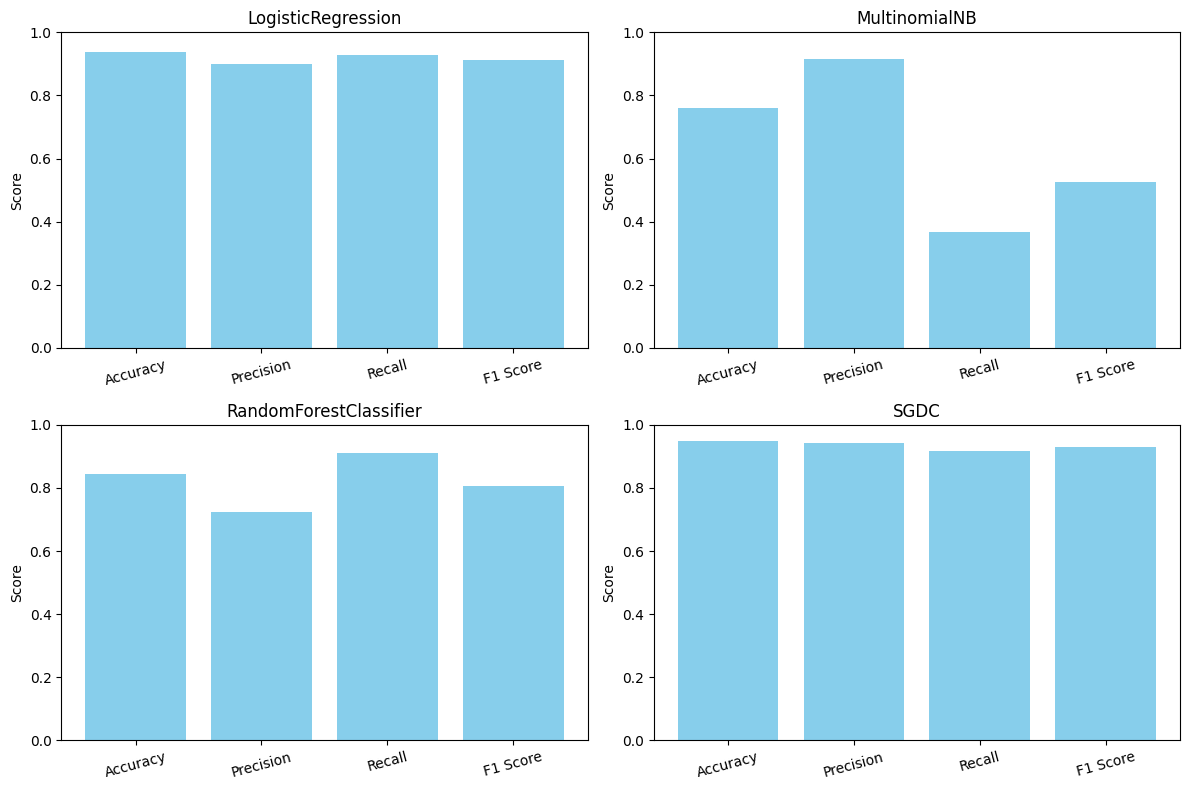

In [100]:
df_plot = results_df.copy()

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Plot each metric in a separate subplot
for i, metric in enumerate(df_plot.index):
    axes[i].bar(df_plot.columns, df_plot.loc[metric], color='skyblue')
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Score")
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## **OBJECTIVE 5**

Use 3-5 trained models for the ensemble approach

For our ensemble approach, let's use logistic regression, SVM, and random forests.

In [101]:
from sklearn.ensemble import VotingClassifier

logreg = LogisticRegression(
        class_weight='balanced', 
        max_iter=1000, 
        C=1.0, 
        n_jobs=-1, 
        solver='saga'
    )
mnb = MultinomialNB()
rf = RandomForestClassifier(
        n_estimators=75, 
        class_weight='balanced', 
        max_depth=12, 
        n_jobs=-1
    )
sgdc = CalibratedClassifierCV(
            SGDClassifier(
            loss='hinge',
            alpha=1/(1.0 * len(X_train)),  # Proper scaling
            class_weight='balanced',
            max_iter=1000,
            n_jobs=-1
        ),
        method='sigmoid',
        cv=3,
        n_jobs=-1
    )

voting_clf = VotingClassifier(
    estimators=[
        ('logreg', logreg),
        ('mnb', mnb),
        ('rf', rf),
        ('sgdc', sgdc)
    ],
    voting='soft',
)

voting_clf.fit(X_train_tfidf, y_train)
y_pred = voting_clf.predict(X_test_tfidf)

ensemble_results = {}

ensemble_results['SoftVoting'] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
}

# Update results DataFrame
res = pd.DataFrame(ensemble_results)
dump(voting_clf, "./serialized/models/EnsembleSoftVoting.pkl")

res.head()

,SoftVoting
Accuracy,0.936879
Precision,0.954955
Recall,0.864600
F1 Score,0.907534


## **OBJECTIVE 6**

Perform inference on sample data with [LIME](https://github.com/marcotcr/lime.git)

In [107]:
# Randomly sample one row from the DataFrame
sample = new_df.sample()
print(f"Original: {sample.values[0]}")

# Extract the text and label as raw values
sample_text = preprocess_text(sample['articles'].values[0], nlp, tagalog_tl, True)
label = sample['labels'].values[0]

print(sample_text, type(sample_text))
print(label, type(label))

Original: ['There can never be enough beauty and other pageants in the Philippines. In fact, this country of more than 100 million people is often referred to as the pageant capital of the world. We’ve had our fair share of international pageant crowns.Now comes yet another pageant like no other, sponsored by top local media like Inquirer, ABS-CBN and Rappler.It’s a twin pageant in search of the very first ‘ Mutya ng Masa’ and ‘Reyna ng Intriga.’Unlike most Philippine pageants, this new pageant franchise has nothing to do with physical beauty; not even brains. It is open only to those who claim to be journalists seeking fame and fortune by peddling intrigue and gossip-based information to the vulnerable public.This year’s dual-theme is: “All sound, no fury,” and “All substance, no content.”Retired queen of all media Kris Aquino will host the pageant finals to be held at the Mall of Asia. The panel of judges is headed by ABS-CBN’s Doris Bigornia, Rappler’s Maria Ressa, self-proclaimed i

In [108]:
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline
import numpy as np

from sklearn.pipeline import make_pipeline

model = load('./serialized/models/EnsembleSoftVoting.pkl')  # Load any model you want to interpret

# Wrap vectorizer and model into one pipeline
c = make_pipeline(vectorizer, model)

class_names = ["Real News", "Fake News"] # 0, 1

In [109]:
explainer = LimeTextExplainer(class_names=class_names)

exp = explainer.explain_instance(sample_text, c.predict_proba, num_features=10)

exp.save_to_file('./figures/sample_lime_explanation.html')

In [110]:
# get pred prob
exp.predict_proba.max()

np.float64(0.886084520431605)

In [111]:
exp.as_list()

[(np.str_('pageant'), 0.05873440311699466),
 (np.str_('ressa'), 0.016293770696707115),
 (np.str_('raissa'), 0.014828735527539648),
 (np.str_('rappler'), 0.0145426109375002),
 (np.str_('patag'), 0.014220340934764488),
 (np.str_('paredes'), 0.01395891098027565),
 (np.str_('philippine'), 0.01207523189405755),
 (np.str_('beauty'), 0.010950997493162366),
 (np.str_('like'), 0.010355867114805425),
 (np.str_('panel'), -0.006221062600688736)]